In [28]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


 Load the data files for gene expression, class labels, and gene ID to symbol mapping


In [29]:
# The file 'class.tsv' contains the labels (ER+ and ER-)
labels = pd.read_csv("class.tsv", sep="\t", header=None, names=['Class'])

# The file 'filtered.tsv' contains the gene expression data for all patients
expression_data = pd.read_csv("filtered.tsv", sep="\t")

# The file 'columns.tsv' contains the mapping of gene IDs to gene names
gene_mapping = pd.read_csv("columns.tsv", sep="\t", comment="#")


Extract the gene IDs for GATA3 and XBP1 from the gene symbol mapping

In [30]:
# Clean the column names by stripping leading/trailing spaces
expression_data.columns = expression_data.columns.str.strip()


In [31]:
# Extract the gene IDs for XBP1 and GATA3 from the gene_mapping file
xpb1_id = gene_mapping.loc[gene_mapping['GeneSymbol'] == 'XBP1', 'ID'].values[0]
gata3_id = gene_mapping.loc[gene_mapping['GeneSymbol'] == 'GATA3', 'ID'].values[0]

# Convert the IDs to string and extract expression data
xpb1_expr = expression_data[str(xpb1_id)].values
gata3_expr = expression_data[str(gata3_id)].values

# Get the class labels for coloring (ER+ and ER- breast cancer)
class_labels = labels['Class'].values


Scatter Plot for XBP1 vs GATA3

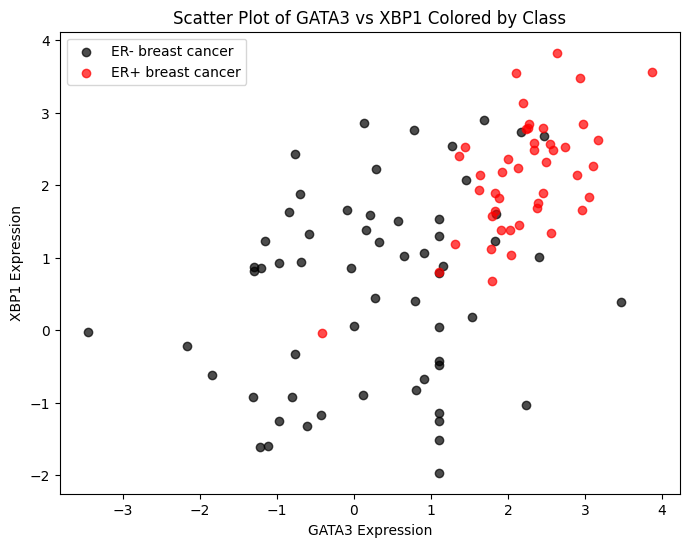

In [32]:
# Plot the scatter plot for GATA3 vs XBP1, colored by class (ER- and ER+)
plt.figure(figsize=(8, 6))
plt.scatter(gata3_expr[class_labels == 0], xpb1_expr[class_labels == 0], color='black', alpha=0.7, label='ER- breast cancer')
plt.scatter(gata3_expr[class_labels == 1], xpb1_expr[class_labels == 1], color='red', alpha=0.7, label='ER+ breast cancer')

# Add labels and title
plt.xlabel("GATA3 Expression")
plt.ylabel("XBP1 Expression")
plt.title("Scatter Plot of GATA3 vs XBP1 Colored by Class")
plt.legend()
plt.show()


2D Scatter Plot of GATA3 vs XBP1 Gene Expression with PCA Vectors

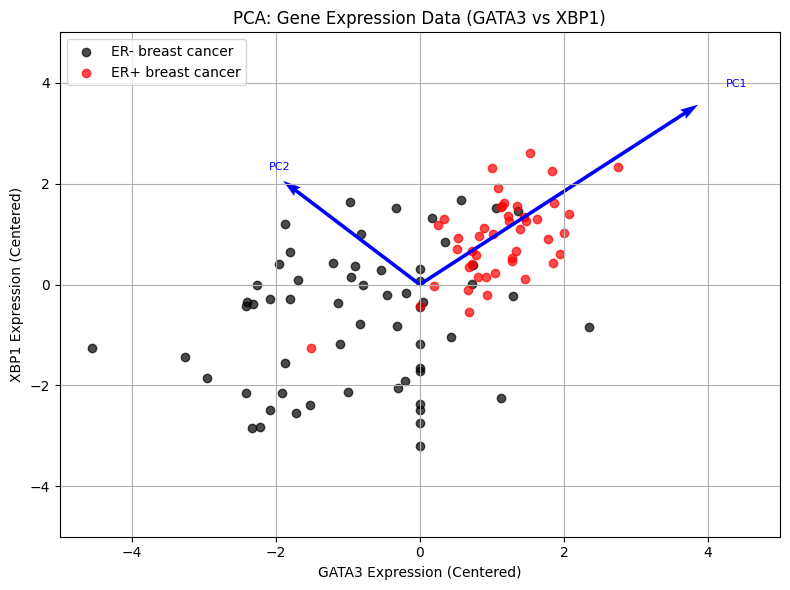

In [24]:
# Stack data (GATA3 and XBP1) into a matrix for PCA
data = np.vstack((gata3_expr, xpb1_expr)).T

#Center the data (subtract the mean)
mean_data = np.mean(data, axis=0)
data_centered = data - mean_data

# Compute covariance matrix
cov_matrix = np.cov(data_centered.T)

#Compute eigenvalues and eigenvectors
eig_vals, eig_vecs = np.linalg.eig(cov_matrix)

#Sort eigenvectors by decreasing eigenvalue
sorted_indices = np.argsort(eig_vals)[::-1]
eig_vals_sorted = eig_vals[sorted_indices]
eig_vecs_sorted = eig_vecs[:, sorted_indices]

#  Project the data onto the first two principal components
projected_data = data_centered @ eig_vecs_sorted[:, :2]

# Plotting the results
plt.figure(figsize=(8, 6))

# Plot original data points
plt.scatter(data_centered[class_labels == 0, 0], data_centered[class_labels == 0, 1],
            color='black', alpha=0.7, label='ER- breast cancer')
plt.scatter(data_centered[class_labels == 1, 0], data_centered[class_labels == 1, 1],
            color='red', alpha=0.7, label='ER+ breast cancer')

# Plot PCA vectors (principal components)
for i in range(2):
    # Vector scaling for visibility
    scale_factor = np.sqrt(eig_vals_sorted[i]) * 3  # Adjust for better visualization
    start_point = np.array([0, 0])
    end_point = eig_vecs_sorted[:, i] * scale_factor

    plt.quiver(start_point[0], start_point[1],
               end_point[0], end_point[1], angles='xy', scale_units='xy', scale=1,
               color='blue', width=0.005)

    # Add text labels for PC1 and PC2
    plt.text(end_point[0]*1.1, end_point[1]*1.1, f'PC{i+1}', color='blue', fontsize=8)

# Labeling
plt.xlabel("GATA3 Expression (Centered)")
plt.ylabel("XBP1 Expression (Centered)")
plt.title("PCA: Gene Expression Data (GATA3 vs XBP1)")
plt.legend()
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.axis()
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()


 Projection of gene expression data (GATA3 and XBP1) onto the first principal component (PC1) from PCA, visualizing the results for ER- and ER+ groups.

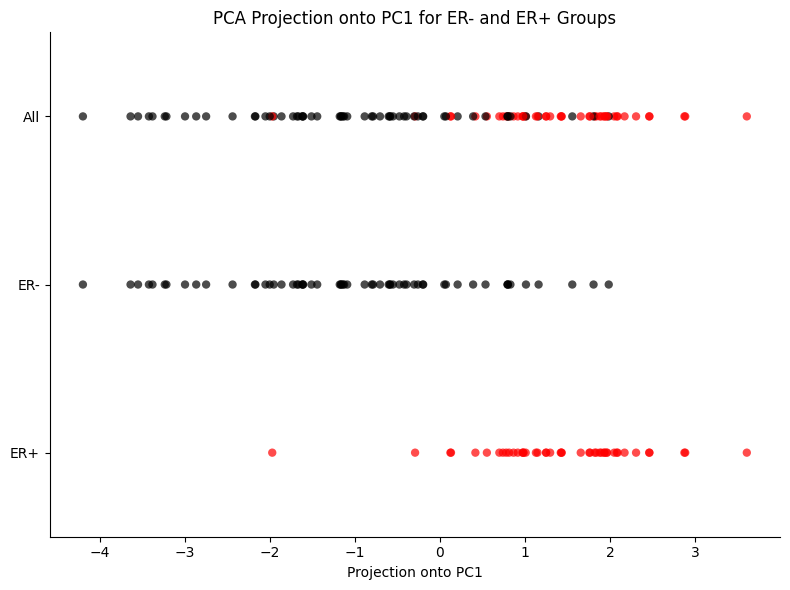

In [27]:
# Project the data onto PC1
pc1_vector = eig_vecs_sorted[:, 0]
pc1_projection = data_centered @ pc1_vector

# Create DataFrames for "All", "ER−", and "ER+" groups
df_all = pd.DataFrame({
    "PC1 Projection": pc1_projection,
    "Group": "All",
    "Color": np.where(class_labels == 0, "black", "red")
})

df_er_minus = pd.DataFrame({
    "PC1 Projection": pc1_projection[class_labels == 0],
    "Group": "ER-",
    "Color": "black"
})

df_er_plus = pd.DataFrame({
    "PC1 Projection": pc1_projection[class_labels == 1],
    "Group": "ER+",
    "Color": "red"
})

# Combine all the groups into one DataFrame
df_projection = pd.concat([df_all, df_er_minus, df_er_plus], ignore_index=True)

#Plot the PCA projection onto PC1 for all three groups
plt.figure(figsize=(8, 6))

# Use seaborn's stripplot to create the visualization
sns.stripplot(data=df_projection, x="PC1 Projection", y="Group", hue="Color",
              palette={"black": "black", "red": "red"}, dodge=False, jitter=False,
              alpha=0.7, size=6)
plt.xlabel("Projection onto PC1")
plt.ylabel("")
plt.title("PCA Projection onto PC1 for ER- and ER+ Groups")

# Remove the legend for clarity (since class colors are already encoded)
plt.legend([], [], frameon=False)
sns.despine()
plt.tight_layout()
plt.show()
